# 1. 直方图分析与均衡化

- 在opencv中，直方图分析与均衡化主要在Image Processing模块的Histograms主题中。主要函数：
    - calcBackProject：反向投影函数，用于在图像中查找与给定直方图模型匹配的区域。
    - calcHist：计算图像直方图的函数。直方图可以表示图像中像素强度的分布情况，常用于图像分析、图像增强、颜色分析等。
    - compareHist：比较两个直方图的相似度，在图像处理和计算机视觉中常用于图像匹配、目标识别等任务。
    - createCLAHE：创建对比度受限的自适应直方图均衡化（CLAHE）对象。
    - EMD：计算两个直方图之间距离的函数。它衡量的是将一个分布转换为另一个分布所需的最小工作量，在图像检索、图像匹配等领域有广泛应用。EMD(Earth Mover's Distance，推土机距离)
    - equalizeHist：直方图均衡化函数，主要用于增强图像对比度，特别是当图像整体偏暗或偏亮时。

## 1.1. 使用calcHist函数计算图像直方图

- calcHist计算一个或多个图像阵列的直方图，是后面很多函数工作的基础，函数可以计算：
    - 灰度图像直方图：显示像素强度分布
    - 彩色图像直方图：计算每个颜色通道的直方图
    - 多维度直方图：计算二维或三维直方图（如颜色直方图）

- calcHist函数的原型定义与参数说明：
    - `cv.calcHist(images, channels, mask, histSize, ranges[, hist[, accumulate]]) -> hist`
    - 函数返回直方图数据结构。
    - images：输入图像列表。要求必须有一样的深度（像素格式：CV_8U, CV_16U or CV_32F）与大小（不要求颜色通道一样）。
    - channels：要计算直方图的通道索引列表。每张图像一次只计算一个通道。
    - mask：设置掩码，只计算掩码区域的直方图。
    - histSize：每个维度的直方图大小（bin的数量）
    - ranges：每个维度的像素值范围
    - accumulate：累积标志，类型是bool类型，如果为 True，直方图不清零。

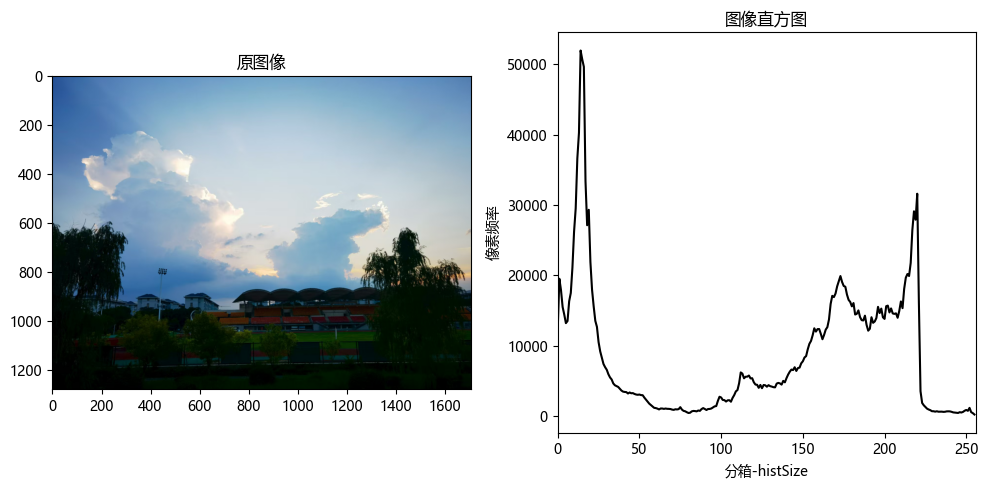

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图像
img = cv2.imread('imgs/scene.jpg', cv2.IMREAD_COLOR_RGB)

hist = cv2.calcHist(
    images=[img], 
    channels=[1], 
    mask=None, 
    histSize=[256], 
    ranges=[0, 256],
    accumulate=True
)
plt.rcParams["font.family"] = ["Microsoft YaHei"]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('原图像')

plt.subplot(1, 2, 2)
plt.plot(hist, color='black')
plt.title('图像直方图')
plt.xlabel('分箱-histSize')
plt.ylabel('像素频率')
plt.xlim([0, 256])
plt.tight_layout()
plt.show()

- 代码说明：
    - calcHist就是按照histSize参数分成指定数量的箱子，并统计每个像素值在指定箱子的数量。所有箱子的数量加在一起就是图像的所有像素的数量。
    - calcHist函数的images参数尽管是一个列表，但是大部分情况下还是处理一张图像。
    - calcHist函数的channels参数类型是列表，可以指定多个通道。指定多个通道不是简单的多个通道，而是单独通过的联合分布，是2D、3D或者多维直方图。
    - calcHist函数的histSize参数类型也是列表，与channels的长度一致，指定分箱数量。
    - calcHist函数的ranges参数参数也是列表，其值是值对，其长度是histSize与channels参数的两倍。
    - 注意：images的指定的图像数量与后面几个参数没有直接关系。但是histSize与channels、ranges参数的长度是相互影响，需要保持一致。

- 下面列子说明两个通道的图像2D直方图。
    - 2D直方图，是分析两个通道构成的像素值的统计信息。一般3D可以直接分析RGB或者BGR意义像素的分布情况。

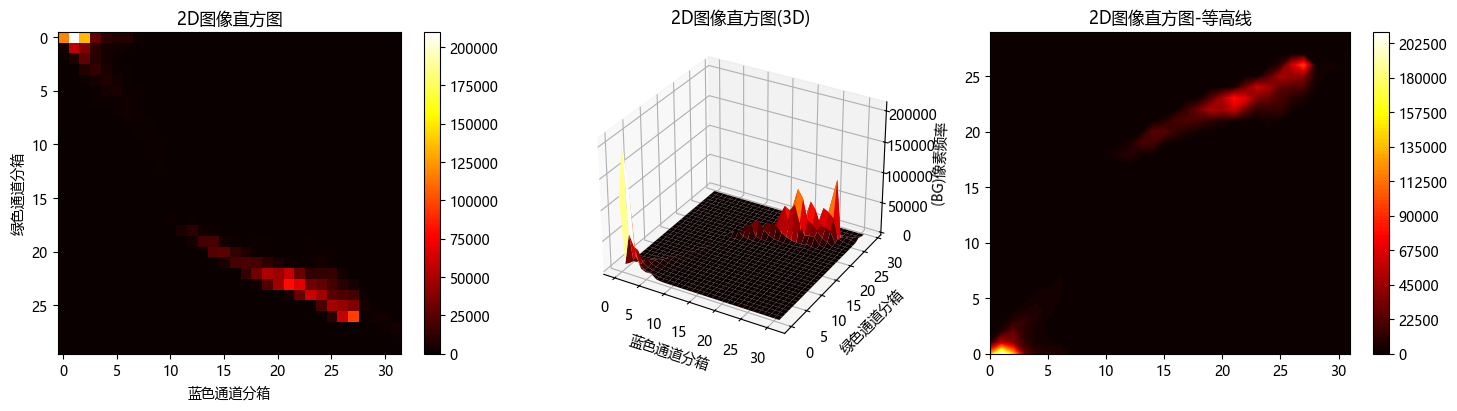

In [84]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

img = cv2.imread('./imgs/scene.jpg')
hist_2d = cv2.calcHist(
    images=[img], 
    channels=[0, 1], 
    mask=None,
    histSize=[30, 32], 
    ranges=[0, 256, 0, 256]    # 不包含256。
)

# 2. 可视化2D直方图
plt.rcParams["font.family"] = ["Microsoft YaHei"]
fig = plt.figure(figsize=(15, 4))
# 使用热力图显示2D直方图
plt.subplot(1, 3, 1)
plt.imshow(hist_2d, cmap='hot')
plt.title('2D图像直方图')
plt.xlabel('蓝色通道分箱')
plt.ylabel('绿色通道分箱')
plt.colorbar()

# 2D直方图的3D曲面图
ax = fig.add_subplot(1, 3, 2, projection='3d')
x = np.arange(hist_2d.shape[1])
y = np.arange(hist_2d.shape[0])
x, y = np.meshgrid(x, y)
ax.plot_surface(x, y, hist_2d, cmap='hot')
ax.set_title('2D图像直方图(3D)')
ax.set_xlabel('蓝色通道分箱')
ax.set_ylabel('绿色通道分箱')
ax.set_zlabel('(BG)像素频率')

# 2D直方图的等高线图
plt.subplot(1, 3, 3)
plt.contourf(hist_2d, 100, cmap='hot')
plt.title('2D图像直方图-等高线')
plt.colorbar()

plt.tight_layout()

- 一般最直观的联合分布分析是基于RGB像素，但是3D不容易表达，下面是图像的3D直方图的表示。

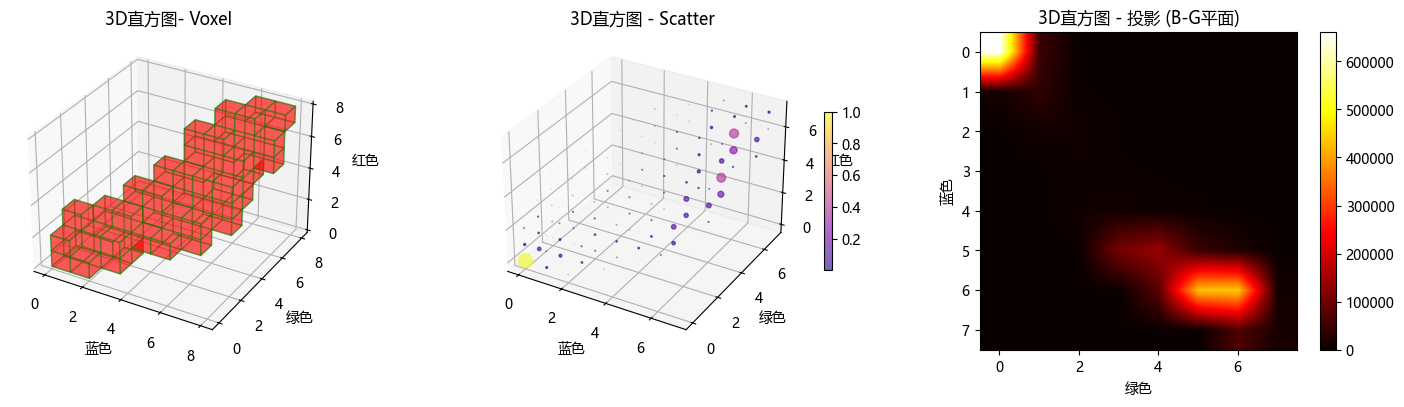

In [82]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import cv2

img = cv2.imread('./imgs/scene.jpg')

# 计算简化的3D直方图（bin较少以便可视化）
hist_3d = cv2.calcHist(
    images=[img], 
    channels=[0, 1, 2], 
    mask=None,
    histSize=[8, 8, 8], 
    ranges=[0, 256, 0, 256, 0, 256]
)

fig = plt.figure(figsize=(15, 4))
# 3D直方图的体素可视化
ax = fig.add_subplot(131, projection='3d')

# 创建体素网格
x, y, z = np.indices((9, 9, 9))

# 阈值处理，只显示频率较高的区域
threshold = np.percentile(hist_3d.flatten(), 90)
mask = hist_3d > threshold

# 绘制体素
ax.voxels(x, y, z, filled=mask, alpha=0.4, facecolor='r', edgecolor='g')
ax.set_title('3D直方图- Voxel')
ax.set_xlabel('蓝色')
ax.set_ylabel('绿色')
ax.set_zlabel('红色')

# 3D直方图的散点图表示
ax = fig.add_subplot(1, 3, 2, projection='3d')

# 提取非零点的坐标和值
nonzero_indices = np.where(hist_3d > 0)
values = hist_3d[nonzero_indices]

# 归一化值用于颜色和大小
norm_values = values / np.max(values)

# 绘制散点
scatter = ax.scatter(
    nonzero_indices[0],  # B通道bin索引
    nonzero_indices[1],  # G通道bin索引
    nonzero_indices[2],  # R通道bin索引
    c=norm_values,       # 颜色根据频率
    s=norm_values * 100, # 大小根据频率
    cmap='plasma',
    alpha=0.6
)
ax.set_title('3D直方图 - Scatter')
ax.set_xlabel('蓝色')
ax.set_ylabel('绿色')
ax.set_zlabel('红色')
plt.colorbar(scatter, ax=ax, shrink=0.5)

# 投影视图
plt.subplot(1, 3, 3)
# 将3D直方图投影到2D平面
projection = np.sum(hist_3d, axis=2)  # 沿R通道投影
plt.imshow(projection, cmap='hot', interpolation='bilinear')
plt.title('3D直方图 - 投影 (B-G平面)')
plt.xlabel('绿色')
plt.ylabel('蓝色')
plt.colorbar()

plt.tight_layout()
plt.show()


- 代码说明：
    - voxels函数是3D坐标的函数（mpl_toolkits.mplot3d.axes3d.Axes3D.voxels），用来绘制体素。
    - 第一个图表使用体素可视化，第二个图表使用3D散点图来可视化，第三个图表使用了投影图（使用sum进行投影）

- mask参数的使用，该参数的注意事项：
    - 必须是uint8类型（8位无符号整数）
    - 必须与原始图像大小完全相同。
    - 必须是单通道。
- mask参数的工作原理：
    - 掩码中值为0的位置：对应像素不参与直方图计算
    - 掩码中值为非0的位置：对应像素参与直方图计算, 通常使用255表示参与计算的区域。

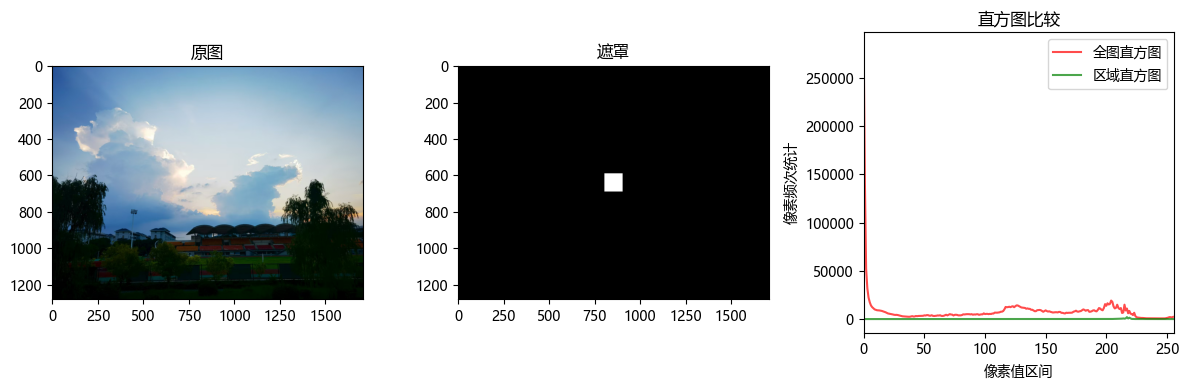

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import cv2

img = cv2.imread('./imgs/scene.jpg', cv2.IMREAD_COLOR_RGB)

# 创建掩码（只计算图像中心区域的直方图）
mask = np.zeros(img.shape[:2], np.uint8)
h, w = img.shape[:2]
center_h, center_w = h // 2, w // 2
mask[center_h-50:center_h+50, center_w-50:center_w+50] = 255

# 计算有掩码和无掩码的直方图
hist_full = cv2.calcHist([img], [0], None, [256], [0, 256])
hist_mask = cv2.calcHist([img], [0], mask, [256], [0, 256])

# 可视化
plt.rcParams["font.family"] = ["Microsoft YaHei"]
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('原图')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title('遮罩')

plt.subplot(1, 3, 3)
plt.plot(hist_full, color='r', label='全图直方图', alpha=0.7)
plt.plot(hist_mask, color='g', label='区域直方图', alpha=0.7)
plt.title('直方图比较')
plt.xlabel('像素值区间')
plt.ylabel('像素频次统计')
plt.legend()
plt.xlim([0, 256])
plt.tight_layout()
plt.show()

## 1.2. 使用compareHist函数比较两个图像的相似度

- compareHist函数的原型定义与参数说明：
    - `cv.compareHist(H1, H2, method) -> retval`
    - 返回两个直方图的相似度。
    - H1参数：设置第一个直方图
    - H2参数：设置第二个直方图
    - method参数：设置直方图的比较方法：
        - HISTCMP_CORREL：相关性方法
            - 基于统计学中的皮尔逊相关系数，衡量两个直方图的线性相关性。
        - HISTCMP_CHISQR：卡方检验
            - 基于卡方统计量，检验两个分布的差异性。用于纹理分析、图像匹配
        - HISTCMP_INTERSECT：交集法
            - 计算两个直方图在每个bin上的最小值之和。
        - HISTCMP_BHATTACHARYYA：Bhattacharyya距离（巴氏距离）
            - 衡量两个概率分布之间的重叠程度。
        - HISTCMP_HELLINGER：Hellinger距离（海林格距离）
            - OpenCV中与Bhattacharyya相同，它是一种用于度量两个概率分布之间差异的统计距离，其核心思想基于两个概率分布密度函数平方根的欧几里得距离。
        - HISTCMP_CHISQR_ALT： Chi-Square Alternate（卡方替代）
            - 卡方检验的变体，使用不同的归一化方式。
        - HISTCMP_KL_DIV：Kullback-Leibler散度 (KL散度)
            - 衡量一个分布相对于另一个分布的信息损失。

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import cv2

img_file1 = "./imgs/scene.jpg"
img_file2 = "./imgs/pukou.jpg"

# 读取并预处理图像
img1 = cv2.imread(img_file1, cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(img_file2, cv2.IMREAD_GRAYSCALE)

# 调整到相同大小(确保像素数量一样多)
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

# 计算直方图
hist1 = cv2.calcHist([img1], [0], None, [256], [0, 256])
hist2 = cv2.calcHist([img2], [0], None, [256], [0, 256])

# 归一化
# cv2.normalize(hist1, hist1, 0, 1, cv2.NORM_MINMAX) # 使用参数作为返回值
hist1 = cv2.normalize(hist1, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)   # None参数是必须的，如果不想参数返回，就设置为None
cv2.normalize(hist2, hist2, 0, 1, cv2.NORM_MINMAX) # 使用参数作为返回值

# 计算相似度（相关性）
similarity1 = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)
similarity2 = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CHISQR)
similarity3 = cv2.compareHist(hist1, hist2, cv2.HISTCMP_INTERSECT)
similarity4 = cv2.compareHist(hist1, hist2, cv2.HISTCMP_BHATTACHARYYA)
similarity5 = cv2.compareHist(hist1, hist2, cv2.HISTCMP_HELLINGER)
similarity6 = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CHISQR_ALT)
similarity7 = cv2.compareHist(hist1, hist2, cv2.HISTCMP_KL_DIV)
print("HISTCMP_CORREL", ":", similarity1)
print("HISTCMP_CHISQR", ":", similarity2)
print("HISTCMP_INTERSECT", ":", similarity3)
print("HISTCMP_BHATTACHARYYA", ":", similarity4)
print("HISTCMP_HELLINGER", ":", similarity5)
print("HISTCMP_CHISQR_ALT", ":", similarity6)
print("HISTCMP_KL_DIV", ":", similarity7)

HISTCMP_CORREL : -0.11004923607922948
HISTCMP_CHISQR : 5041416.864158424
HISTCMP_INTERSECT : 9.92690066945579
HISTCMP_BHATTACHARYYA : 0.4711031941155409
HISTCMP_HELLINGER : 0.4711031941155409
HISTCMP_CHISQR_ALT : 28.420280290255512
HISTCMP_KL_DIV : 82.81820037870915


- 代码说明：
    - 负相关是具有物理意义的，表示两个直方图在分布上呈现相反的趋势：
        - 一个直方图峰值的地方，另一个直方图恰好是谷值（一个直方图数值高的区间，另一个直方图数值低）
    - 代码中使用normalize函数对直方图数据进行了归一化处理，并在计算直方图之前，对图像的大小做了统一计算。
    - 上面相似性计算方法的优缺点：
        - 相关性（HISTCMP_CORREL）：对直方图缩放不敏感（光照变化），能检测负相关关系。对直方图平移敏感。
        - 卡方检验（HISTCMP_CHISQR）：对低频差异敏感，对高频小差异不敏感。
        - 相交法（HISTCMP_INTERSECT）：计算速度快，对部分遮挡鲁棒，对直方图整体位移敏感。
        - Bhattacharyya距离（HISTCMP_BHATTACHARYYA）：对称性好，有统计意义（衡量分布重叠度），对分布形状敏感。
        - Hellinger距离（HISTCMP_HELLINGER）：海林格距离的值始终在 0 和 1 之间。0 当且仅当两个分布完全相同，1 表示两个分布是完全不相交的
        - K-L散度/相对熵（HISTCMP_KL_DIV）： 对概率分布差异敏感，非对称性
    - 在选择相似性计算方法的时候的建议：
        - 没有绝对最好的方法，但相关性方法（CORREL）通常是最安全、综合表现最好的选择。
        - 对于特定应用，可以根据需要选择专门的方法，或者组合多个方法获得更好的效果。

## 1.3. 使用calcBackProject函数查找特定颜色区

- calcBackProject 函数的工作原理
    - 反向投影：计算图像中每个像素属于目标直方图的概率
    - 工作原理：将图像中每个像素的值替换为在目标直方图中对应 bin 的值
    - 应用场景：目标跟踪、图像分割、颜色匹配等

- calcBackProject 函数的原型定义与参数说明：
    - `cv.calcBackProject(images, channels, hist, ranges, scale[, dst]) -> dst`
        - images：需要处理的图像，参数类型是列表，可以处理以一张或者多张图像。图像必须有一样的深度（CV_8U, CV_16U or CV_32F），大小。
        - channels：用于反向投影的通道列表，
        - hist：输入的直方图（使用calcHist计算得到），用于计算反向投影（计算图像中每个像素属于目标直方图的概率），
        - ranges：每个通道的像素值范围。
        - scale：输出反向投影结果的缩放因子，

(1279, 1706)


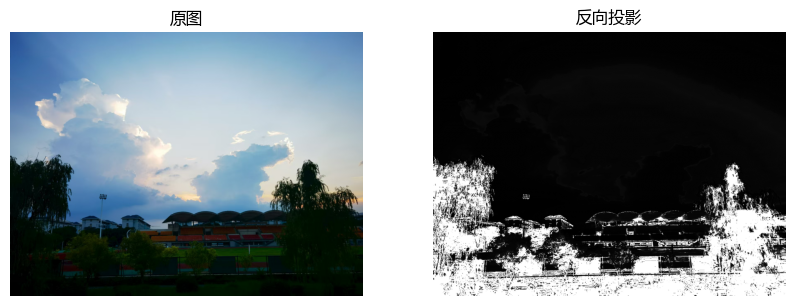

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# 读取图像
img = cv2.imread("./imgs/scene.jpg", cv2.IMREAD_COLOR_RGB)

# 计算直方图（仅使用 B 通道）
hist = cv2.calcHist([img], [0], None, [180], [0, 180])
cv2.normalize(hist, hist, 0, 255, cv2.NORM_MINMAX)

# 计算反向投影
back_proj = cv2.calcBackProject([img], [0], hist, [0, 256], 1)
print(back_proj.shape)

# 可视化
plt.rcParams["font.family"] = ["Microsoft YaHei"]
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.title('原图')
plt.axis('off')

plt.subplot(122),
plt.imshow(back_proj, cmap='gray')
plt.title('反向投影')
plt.axis('off')
plt.show()

- 应用：使用calcBackProject查找特定颜色区域

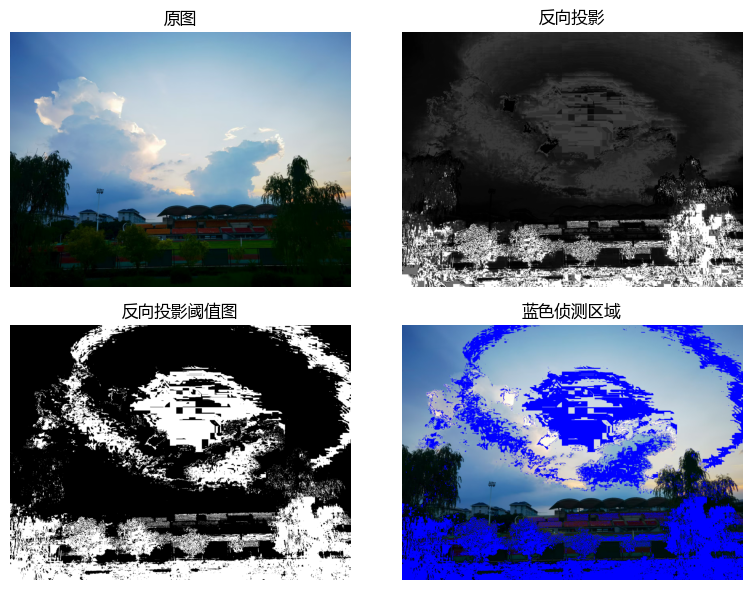

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图像
img = cv2.imread("./imgs/scene.jpg", cv2.IMREAD_COLOR_RGB)

# 计算目标直方图（使用 Blue 通道）
hist = cv2.calcHist([img], [2], None, [256], [0, 256])
cv2.normalize(hist, hist, 0, 255, cv2.NORM_MINMAX)

# 计算反向投影
back_proj = cv2.calcBackProject([img], [2], hist, [0, 256], 1)

# 应用阈值获取二值图像
_, mask = cv2.threshold(back_proj, 50, 255, cv2.THRESH_BINARY)

# 显示结果
plt.rcParams["font.family"] = ["Microsoft YaHei"]
plt.figure(figsize=(8, 6))

plt.subplot(221)
plt.imshow(img)
plt.title('原图')
plt.axis('off')

plt.subplot(222), 
plt.imshow(back_proj, cmap='gray')
plt.title('反向投影')
plt.axis('off')

plt.subplot(223) 
plt.imshow(mask, cmap='gray')
plt.title('反向投影阈值图'), plt.axis('off')
# 在原图上标记检测区域
result = image.copy()
result[mask == 255] = [0, 0, 255]  # 用blue标记

plt.subplot(224)
plt.imshow(result)
plt.title('蓝色侦测区域')
plt.axis('off')

plt.tight_layout()
plt.show()

- 代码说明：
    - 使用反向投用来跟踪颜色区域的原理比较简单，就是对某个颜色通道进行像素统计，并把原图的像素替换成像素统计值。从而得到反向投影图，并通过阈值处理，对阈值反向投影图进行颜色标注，从而达到颜色跟踪的目的。
    - 其中bin的统计值范围不在0-256之间，一般使用normalize进行0-256的归一化处理。

## 1.4. 使用equalizeHist进行图像增强

- equalizeHist是OpenCV 中的直方图均衡化函数，主要用于增强图像对比度，特别是当图像整体偏暗或偏亮时。

- equalizeHist函数的原型定义与参数说明：
    - `cv.equalizeHist(src[, dst]	) -> dst`
        - src参数：设置需要进行直方图均衡化的图像。
        - dst参数：返回直方图均衡化以后得图像。

- 灰度图像的直方图均衡化效果

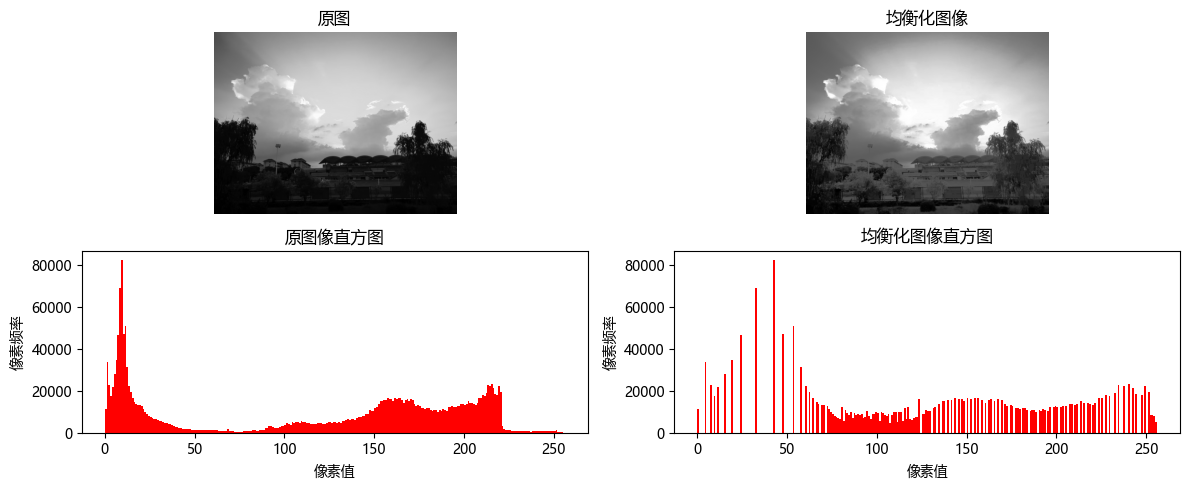

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图像（灰度模式）
img = cv2.imread("./imgs/scene.jpg", cv2.IMREAD_GRAYSCALE)
# 应用直方图均衡化
equalized_img = cv2.equalizeHist(img)

# 显示原图和均衡化后的图像
plt.rcParams["font.family"] = ["Microsoft YaHei"]
plt.figure(figsize=(12, 5))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('原图')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(equalized_img, cmap='gray')
plt.title('均衡化图像')
plt.axis('off')

# 显示直接计算的直方图对比
plt.subplot(2, 2, 3)
plt.hist(img.ravel(), 256, range=[0, 256], color='r')
plt.title('原图像直方图')
plt.xlabel('像素值')
plt.ylabel('像素频率')

plt.subplot(2, 2, 4)
plt.hist(equalized_img.ravel(), 256, range=[0, 256], color='r')
plt.title('均衡化图像直方图')
plt.xlabel('像素值')
plt.ylabel('像素频率')

plt.tight_layout()
plt.show()

- 代码说明：
    - 图像直方图均衡化的主要原理是：将原始图像的灰度直方图从任意分布变换为近似均匀分布，使灰度级分布更均匀，从而增强对比度。
    - 通过一个变换函数，对灰度进行变换：$s=T(r)$
        - r是输入灰度
        - s是变换后灰度（而且理想状态是输出的灰度是均匀分布：$p(s)= \dfrac{1}{(L-1)}$。
    - 变换函数的的推导：
        - 假设输入r的概率分布函数为$p_r(r)$，输出s的概率分布是$p_s(s)=\dfrac{1}{(L-1)}:均匀分布$
        - 在随机变量r变化为s的变量变换下，其概率密度分布函数的变换公式表示如下：$p_s(s)= p_r(r)|\dfrac{dr}{ds}|$
        - 在s满足均匀分布的情况下，可以表示为：$\dfrac{ds}{dr}=(L-1) p_r(r)$
        - 对上面表达式做积分运算得到：$s=T(r)=(L-1)\int \limits _0 ^r p_r(w) dw$
    - 表达为离散形式为：$s_k = T(r_k) = (L-1) * \sum \limits _{j=0}^{k} p_r(r_j) = (L-1) / MN * \sum \limits _{j=0}^{k} n_j$
        - $M x N$是图像的尺寸。
        - $n_j$是灰度为$r_j$的像素数量（直方图中的统计值）
        - $p_r(r_j) = n_j / (MN)$是灰度$r_j$的概率。

- 上面是对灰度图像的均衡化，下面我们对彩色图形进行均衡化处理。

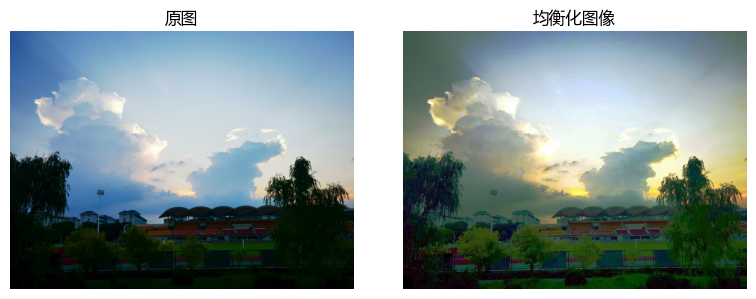

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取彩色图像
img = cv2.imread("./imgs/scene.jpg", cv2.IMREAD_COLOR_RGB)

equalized_img = img.copy()
# 对RGB通道进行直方图均衡化
equalized_img[:, :, 0] = cv2.equalizeHist(img[:, :, 0])
equalized_img[:, :, 1] = cv2.equalizeHist(img[:, :, 1])
equalized_img[:, :, 2] = cv2.equalizeHist(img[:, :, 2])

plt.rcParams["font.family"] = ["Microsoft YaHei"]
plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.imshow(img)
plt.title('原图')
plt.axis('off')

plt.subplot(122)
plt.imshow(equalized_img)
plt.title('均衡化图像')
plt.axis('off')

plt.tight_layout()
plt.show()


- 代码说明：
    - 代码中分别对RGB通道进行均衡化，然后合并成彩色图像。
    - 实际上可以使用另外颜色空间YUV处理会更好。
        - Y（Luma）：代表亮度（明暗）信息。这部分包含了人眼最敏感的细节信息。
        - UV（Chrominance）：代表色度（颜色）信息。U 和 V 分别是蓝色差（B-Y）和红色差（R-Y）信号。
        - 黑白电视机可以只处理 Y 信号来显示黑白图像，而彩色电视则同时处理 Y 和 UV 信号来显示彩色。
        - 我们可以只处理Y来进行颜色亮度处理。

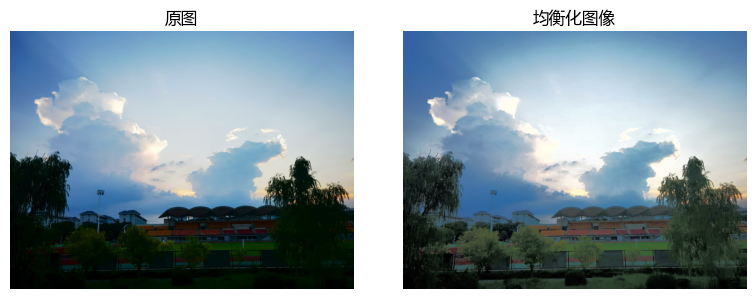

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取彩色图像
img = cv2.imread("./imgs/scene.jpg", cv2.IMREAD_COLOR_RGB)

# 转换为YUV色彩空间（Y分量代表亮度）
img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)

# 对Y通道进行直方图均衡化
img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])

# 转换回BGR
equalized_img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)
    
plt.rcParams["font.family"] = ["Microsoft YaHei"]
plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.imshow(img)
plt.title('原图')
plt.axis('off')

plt.subplot(122)
plt.imshow(equalized_img)
plt.title('均衡化图像')
plt.axis('off')

plt.tight_layout()
plt.show()


- 代码说明：
    - 使用亮度处理，效果比上面RGB颜色通道同时处理的效果要好，因为RGB的直方图分布可能不一致，导致在均衡化处理液不一致。

## 1.5. 使用createCLAHE函数进行图像增强处理

- createCLAHE函数用于创建对比度受限的自适应直方图均衡化（CLAHE）对象。与普通直方图均衡化相比有两大优势：
    - 自适应：将图像分成小区域（tiles）分别进行直方图均衡化
    - 对比度限制：防止局部区域过度增强产生噪声。

- createCLAHE函数的原型定义与参数说明：
    - `cv.createCLAHE([, clipLimit[, tileGridSize]]	) -> retval`
        - 返回均衡卷后的图像。
        - clipLimit参数：设置对比度限制阈值（默认40.0）
        - tileGridSize参数：网格大小，格式为(rows, cols)，默认(8, 8)

- cv::CLAHE对象的核心函数
    - `cv.CLAHE.apply( src[, dst]) -> dst`
        - 使用对比度受限自适应直方图均衡化方法对灰度图像的直方图进行均衡化处理。
        - src设置需要均衡化处理的灰度图像。
        - dst返回均衡处理后的图像。
- cv::CLAHE对象的属性访问
    - clipLimit属性访问：
        - `cv.CLAHE.getClipLimit( ) -> retval`：获取clipLimit属性
        - `cv.CLAHE.setClipLimit( clipLimit ) -> None`：设置clipLimit属性
    - tileGridSize属性访问：
        - `cv.CLAHE.getTilesGridSize( )->retval`：获取tileGridSize属性
        - `cv.CLAHE.setTilesGridSize( tileGridSize ) -> None`：设置tileGridSize属性
- cv::CLAHE对象的垃圾回收函数（对象内存释放）
    - `cv.CLAHE.collectGarbage( ) -> None`  

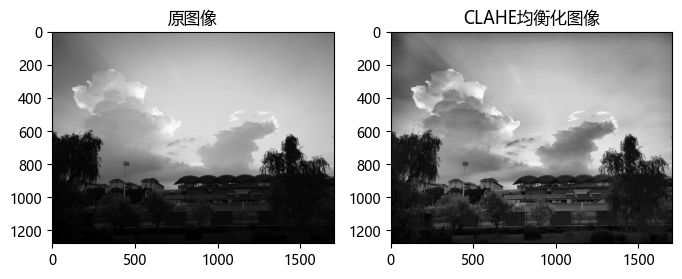

In [36]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
# 读取彩色图像
img = cv2.imread("./imgs/scene.jpg", cv2.IMREAD_GRAYSCALE)

# 创建CLAHE对象
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# 应用CLAHE进行均衡化处理
img_clahe = clahe.apply(img)

# 对比原图和CLAHE结果
plt.rcParams["font.family"] = ["Microsoft YaHei"]
plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.title('原图像')

plt.subplot(122)
plt.imshow(img_clahe, cmap='gray')
plt.title('CLAHE均衡化图像')
plt.show()

- 代码说明：
    - 代码中我们使用灰度图像来进行均衡化，类似前面equalizeHist函数的处理方式，可以使用YUV的亮度通道，以及对三个通道分别处理。

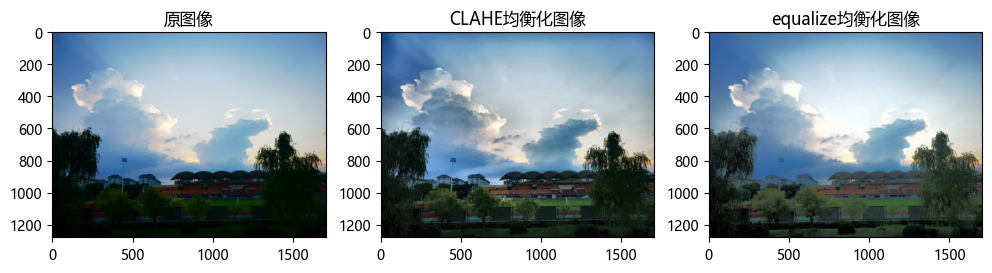

In [34]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
# 读取彩色图像
img = cv2.imread("./imgs/scene.jpg", cv2.IMREAD_COLOR_RGB)
# 转换为YUV色彩空间（Y分量代表亮度）
img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)

img_clahe = img_yuv.copy()
img_equal = img_yuv.copy()

# ---------------------------------------------------------
# 创建CLAHE对象
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
# 应用CLAHE进行均衡化处理
img_clahe[:, :, 0] = clahe.apply(img_clahe[:, :, 0])

# ---------------------------------------------------------
# 对Y通道进行直方图均衡化
img_equal[:, :, 0] = cv2.equalizeHist(img_equal[:, :, 0])
# ---------------------------------------------------------

# 转换为RGB
img_clahe = cv2.cvtColor(img_clahe, cv2.COLOR_YUV2RGB)
img_equal = cv2.cvtColor(img_equal, cv2.COLOR_YUV2RGB)

# 对比原图和CLAHE结果
plt.rcParams["font.family"] = ["Microsoft YaHei"]
plt.figure(figsize=(12, 3))
plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title('原图像')

plt.subplot(132)
plt.imshow(img_clahe, cmap='gray')
plt.title('CLAHE均衡化图像')

plt.subplot(133)
plt.imshow(img_equal, cmap='gray')
plt.title('equalize均衡化图像')

plt.show()

- 代码说明：
    - 使用CLAHE均衡化的图像，视觉效果要好很多（明暗对比度很符合人类视觉）。这是局部自适应的效果，受局部影响，不受整体影响。

## 1.6. 使用EMD函数比较来个图像的分布

- EMD（Earth Mover's Distance，推土机距离）是OpenCV中用于计算两个直方图之间距离的函数。它衡量的是将一个分布转换为另一个分布所需的最小工作量，在图像检索、图像匹配等领域有广泛应用。
- EMD将两个分布看作两堆土，计算将一堆土搬运成另一堆土所需的最小工作量（距离×质量）。与直方图比较方法（如相关系数、卡方等）相比，EMD能更好地处理分布的整体形状相似性。

- EMD函数的原型定义与参数说明：
    - `cv.EMD(signature1, signature2, distType[, cost[, lowerBound[, flow]]]) -> retval, lowerBound, flow`
        - 返回值：
            - retval：计算出的EMD距离。
            - lowerBound：下界距离。
            - flow：流矩阵，形状为 (n, m)，表示从签名1到签名2的运输量
        - 参数：
            - signature1：第一个签名，形状为 (n, dims+1)，类型需要是float。
                - n表示行，dims+1表示列，每一行的dims+1表示为：其中1表示权重系数，权重系数的和最好是1，但是这不是必须的（EMD会自动处理），权重必须是非负数。
            - signature2：第二个签名，与signature1一样。
            - distType：距离类型，通常有如下距离类型：
                - DIST_USER：用户自定义距离计算公式，通过cost参数提供
                - DIST_L1：曼哈顿距离（绝对值差之和），计算公式|x1-x2| + |y1-y2|
                - DIST_L2：欧几里得距离（主要使用）
                - DIST_C： 棋盘距离/切比雪夫距离（最大绝对差），计算公式 max(|x1-x2|,|y1-y2|)
                - DIST_L12
                - DIST_FAIR
                - DIST_WELSCH
                - DIST_HUBER
            - cost：自定义成本矩阵。

- 使用EMD函数，需要对特殊的直方图签名格式。

In [38]:
import cv2
import numpy as np

# 创建两个1D分布的签名
# 分布1
sig1 = np.array([
    [0.4, 0.0],  # 40%的质量在位置0
    [0.6, 1.0]   # 60%的质量在位置1
], dtype=np.float32)

# 分布2：集中在右侧
sig2 = np.array([
    [0.3, 2.0],  # 30%的质量在位置2
    [0.7, 3.0]   # 70%的质量在位置3
], dtype=np.float32)

# 计算EMD距离（使用L2距离）
emd_distance, _, flow = cv2.EMD(sig1, sig2, cv2.DIST_L2)

print(f"EMD距离: {emd_distance:.4f}")
print(f"流矩阵:\n{flow}")

EMD距离: 2.1000
流矩阵:
[[0.3        0.09999999]
 [0.         0.6       ]]


- 代码说明：
    - 代码中说明了签名的格式与使用。
    - EMD主要用来衡量两个分布的相似性。

- 在图像的像素分布相似性衡量中，主要是把图像直方图转换为签名格式。

图像色调直方图EMD距离: 0.036282431334257126


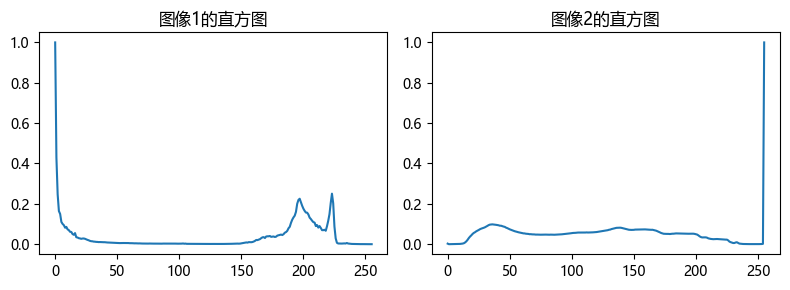

In [50]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def hist_to_signature(hist, bin_centers=None):
    """将直方图转换为EMD签名格式"""
    hist = hist.flatten()
    if bin_centers is None:
        # 如果没有提供bin中心，使用索引作为特征
        bin_centers = np.arange(len(hist)).reshape(-1, 1)
    
    # 归一化直方图作为权重
    weights = hist.astype(np.float32)
    
    # 创建签名：[特征, 权重]
    signature = np.zeros((len(hist), 2), dtype=np.float32)
    
    for i in range(len(hist)):
        signature[i, 0] = bin_centers[i, 0]
        signature[i, 1] = weights[i]
    return signature

# 读取两张图像
img1 = cv2.imread("./imgs/scene.jpg")
img2 = cv2.imread("./imgs/pukou.jpg")



# 计算色调(H)通道的直方图
hist1 = cv2.calcHist([img1], [0], None, [256], [0, 256])
hist2 = cv2.calcHist([img2], [0], None, [256], [0, 256])

# 归一化直方图
cv2.normalize(hist1, hist1, 0, 1, cv2.NORM_MINMAX)
cv2.normalize(hist2, hist2, 0, 1, cv2.NORM_MINMAX)

# 转换为签名
# 使用bin中心作为特征
bin_centers = np.arange(256).reshape(-1, 1).astype(np.float32)
signature1 = hist_to_signature(hist1, bin_centers)
signature2 = hist_to_signature(hist2, bin_centers)

# 计算EMD距离
distance, _, _ = cv2.EMD(signature1, signature2, cv2.DIST_L2)
print(f"图像色调直方图EMD距离: {distance}")

# 可视化直方图
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(hist1)
plt.title('图像1的直方图')
plt.subplot(1, 2, 2)
plt.plot(hist2)
plt.title('图像2的直方图')
plt.tight_layout()
plt.show()

- 代码说明:
    - 对图像的1D直方图，进行签名的处理方式就是：
        - 第一列是根据bins的数量生成的序号1,2,3,....。
        - 第二列是直方图的统计数据（归一化后的直方图统计数据）
    - 根据直方图的分布，以及计算的结果，两幅图像基本上在B蓝色通道，相似度非常低。

- 下面对彩色图像的2D/3D直方图比较相似性。

In [54]:
import cv2
import numpy as np

def create_2d_hist_signature(img, bins=32):
    # 计算2D直方图（H和S通道）
    hist = cv2.calcHist([img], [0, 1, 2], None, [bins, bins, bins], [0, 256, 0, 256, 0, 256])
    hist = cv2.normalize(hist, None, 0, 1, cv2.NORM_MINMAX)
    
    # 创建签名
    indices = np.indices((bins, bins, bins)).reshape(3, -1).T.astype(np.float32)
    weights = hist.reshape(-1, 1).astype(np.float32)
    
    # 组合成签名数组
    signature = np.hstack([indices, weights])
    # print(indices)
    # print(indices.shape)
    # print(weights.shape)
    # print(signature.shape)
    return signature

# 创建两个示例图像
# 读取两张图像
img1 = cv2.imread("./imgs/scene.jpg")
img2 = cv2.imread("./imgs/pukou.jpg")

# 创建2D/3D直方图签名
signature1 = create_2d_hist_signature(img1, bins=16)
signature2 = create_2d_hist_signature(img2, bins=16)

# 计算EMD距离
distance, _, flow = cv2.EMD(signature1, signature2, cv2.DIST_L2)
print(f"3D颜色直方图EMD距离: {distance}")

2D颜色直方图EMD距离: 0.0034419952426105738


- 代码说明：
    - 对于2D/3D直方图的计算量会比较大，计算时间较久。
    - 代码签名的格式如下：每行 `[特征1, 特征2, ..., 权重]`
        - 最后一列是权重，前面的是特征维度（或者称之为特征坐标）

- 应用：
    - 进行图像的纹理分析与匹配。
    - 进行目标跟踪与匹配。
    - 进行图像分类与识别。
    - 进行图像质量评估。